#HW 5 - CNN Sketch Classification (10 pts)

For homework assignment HW 5, you will implement a sketch classifier using the Google QuickDraw dataset:
1. Select at least 5 classes for training and testing.

2. Baseline Implementation: implement the classifier using Lab 2 architecture to establish a performance baseline. (1/10 pts)

3. Re-implement the classifier using CNN and conduct experiments to compare the performance of the classic NN against the CNN. (5/10 pts)

4. Experiment Report (max 6 pages): You are required to conduct a comparative performance analysis of your models with at least 100 test sketches (from the dataset) for each class. You **MUST** experiment with different model configurations for your CNN (e.g. different hidden layer size, more or less convolution layers, batch norm, dropout, etc.) to make it better. Document your findings with comparative screenshots of classification outputs and specify the configuration that gives you the best results. Report the accuracy rate for different model configurations. (4/10 pts)


Note:
1. You can use smaller training data size (so faster training) as long as you get reasonable classification results.
2. You can split the dataset, use a subset as training set and use another 100 or more sketches as the test set.

In [1]:
# Hyperparameters

batch_size = 64
learning_rate = 0.001
epochs = 10
max_items = 1000   # per category
train_size, test_size = 0.8, 0.2
device = 'cpu'



In [2]:
from pathlib import Path
import os
import time
import urllib.request

import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms



# Colab root
data_dir = Path(".")

# Define categories to download
# See all the categories at:
# https://github.com/googlecreativelab/quickdraw-dataset/blob/master/categories.txt

base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

# 5 classes
categories = [
    "cat",
    "fish",
    "flower",
    "star",
    "tree"
]

for cat in categories:
    url = f"{base_url}{cat.replace(' ', '%20')}.npy"    # replace spaces with %20
    path = data_dir / f"{cat}.npy"
    if not os.path.exists(path):
        print(f"Downloading {cat}...")
        urllib.request.urlretrieve(url, path)

In [3]:
class QuickDrawDataset(Dataset):
    def __init__(self, root, categories, max_items=10000, transform=None):
        super().__init__()
        self.data, self.labels = [], []
        self.transform = transform

        for idx, cat in enumerate(categories):
            # Load as raw uint8 (0 - 255)
            data = np.load(f"{root}/{cat}.npy")[:max_items]

            self.data.append(data)
            self.labels.extend([idx] * len(data))

        self.data = np.concatenate(self.data).astype(np.uint8)
        self.labels = np.array(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].reshape(28, 28)
        label = self.labels[idx]

        # Apply transforms
        if self.transform:
            image = self.transform(image)
        return image, label


# Setup

raw_dataset = QuickDrawDataset(root=data_dir, categories=categories, max_items=max_items)
loader = DataLoader(raw_dataset, batch_size=batch_size)

train_dataset, test_dataset = random_split(raw_dataset, [train_size, test_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

""" This only finds the mean/std of a single batch """
# all_images, all_labels = next(iter(loader))

all_images = []
all_labels = []
for images, labels in loader:
    all_images.append(images)
    all_labels.append(labels)
all_images = torch.cat(all_images, dim=0)
all_labels = torch.cat(all_labels, dim=0)

all_images = all_images.float()
all_mean, all_std = all_images.mean().item(), all_images.std().item()

# Because the ToTensor transform (below) divides its data by 255, these
# should be normalized too
all_mean = all_mean / 255.0
all_std = all_std / 255.0

raw_dataset.transform = transforms.Compose([
    # ToTensor() scales uint8 by 255 internally: [0, 255] -> [0.0, 1.0]
    transforms.ToTensor(),
    transforms.Normalize((all_mean,), (all_std,))
])

In [4]:
configs = {
    "config_1": {
        "name": "Baseline NN",
        "model": nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, len(categories)),
        ),
    },
    "config_2": {
        "name": "CNN-A",
        "model": nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*14*14, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, len(categories)),
        ),

    },
    "config_3": {
        "name": "CNN-B",
        "model":nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*14*14, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, len(categories)),
        ),
    },
    "config_4": {
        "name": "CNN-C",
        "model":nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, len(categories)),
        ),
    },
    "config_5": {
    "name": "CNN-D",
    "model":nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(32*7*7, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, len(categories)),
    ),
  },
}

In [5]:
# Neural network for classification
class Net(nn.Module):
    def __init__(self, layers: nn.Sequential):
        super(Net, self).__init__()
        self.layers = layers

    def forward(self, x):
        return self.layers(x)

def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for (data, target) in loader:
            output = model(data)

            pred_idx = output.argmax(dim=1)

            correct += (pred_idx == target).sum().item()
            total += target.size(0)

    return correct / total

def train(config):

  model = Net(layers=config["model"])


  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  criterion = nn.CrossEntropyLoss()

  # Training
  losses = []
  accuracies = []

  print('\n##', config["name"])

  for epoch in range(epochs):
      model.train()

      correct = 0
      total = 0

      for batch_idx, (data, target) in enumerate(train_loader):
          optimizer.zero_grad()
          output = model(data)
          loss = criterion(output, target)
          loss.backward()
          optimizer.step()

          if batch_idx % 100 == 0:
              losses.append(loss.item())

      accuracy = evaluate(model, test_loader)
      accuracies.append(accuracy)

      print(f"Epoch {epoch+1} complete.")

  print(f"Test Accuracy: {accuracies[-1]:.2f}")

  return model, losses, accuracies


In [6]:
config_list = list(configs.values())
models = []

losses = []
accuracies = []


for config in config_list:
    model, loss, accuracy = train(config)

    models.append(model)
    losses.append(loss)
    accuracies.append(accuracy)





## Baseline NN
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.
Epoch 6 complete.
Epoch 7 complete.
Epoch 8 complete.
Epoch 9 complete.
Epoch 10 complete.
Test Accuracy: 0.86

## CNN-A
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.
Epoch 6 complete.
Epoch 7 complete.
Epoch 8 complete.
Epoch 9 complete.
Epoch 10 complete.
Test Accuracy: 0.89

## CNN-B
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.
Epoch 6 complete.
Epoch 7 complete.
Epoch 8 complete.
Epoch 9 complete.
Epoch 10 complete.
Test Accuracy: 0.91

## CNN-C
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.
Epoch 6 complete.
Epoch 7 complete.
Epoch 8 complete.
Epoch 9 complete.
Epoch 10 complete.
Test Accuracy: 0.92

## CNN-D
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.
Epoch 6 complete.
Epoch 7 complete.
Epoch 8 comple

In [7]:
# stability: average absolute difference

for i, config in enumerate(config_list):

    loss_diff = np.abs(np.diff(losses[i]))

    avg_diff = np.mean(loss_diff)       # stability
    last_diff = loss_diff[-1]           # how stable at the end

    print(config["name"], f"{avg_diff=:.3f}, {last_diff=:.3f}")



Baseline NN avg_diff=0.175, last_diff=0.047
CNN-A avg_diff=0.180, last_diff=0.013
CNN-B avg_diff=0.192, last_diff=0.030
CNN-C avg_diff=0.241, last_diff=0.135
CNN-D avg_diff=0.211, last_diff=0.020


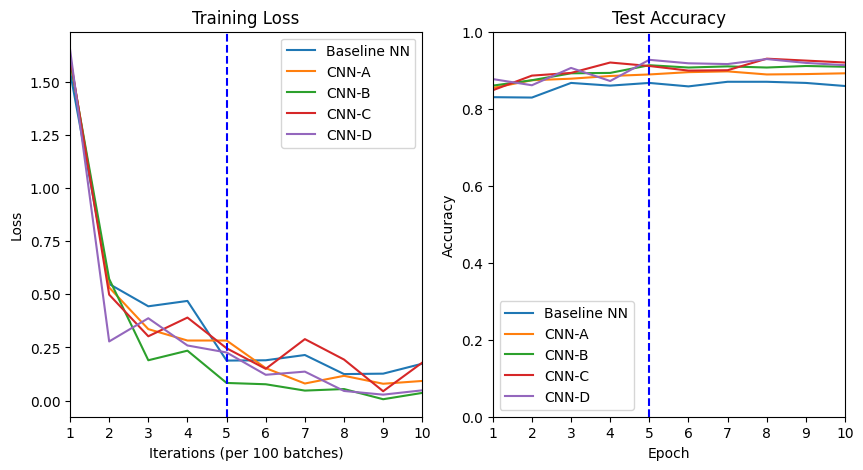

In [8]:
# Plots

_, axs = plt.subplots(1, 2, figsize=(10, 5))

batch_count = np.linspace(0, 100*len(train_loader), 100)
for i, config in enumerate(config_list):
    axs[0].plot(losses[i], label=config["name"])
    axs[1].plot(accuracies[i], label=config["name"])

axs[0].set_title("Training Loss")
axs[0].set_xlabel("Iterations (per 100 batches)")
axs[0].set_ylabel("Loss")
# axs[0].grid(True)
axs[0].legend()
axs[0].axvline(epochs//2-1, ls='--', c='blue')
axs[0].set_xticks(range(epochs))
axs[0].set_xticklabels(range(1, epochs+1))
axs[0].set_xlim(0, 9)

axs[1].set_title("Test Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
# axs[1].grid(True)
axs[1].legend()
axs[1].set_ylim(0, 1)
axs[1].axvline(epochs//2-1, ls='--', c='blue')
axs[1].set_xticks(range(epochs))
axs[1].set_xticklabels(range(1, epochs+1))
axs[1].set_xlim(0, 9)


plt.show()

Drawing Canvas for Testing

In [ ]:
import numpy as np
from IPython.display import HTML, display
from google.colab import output
import json
import cv2
import torch
import base64
import matplotlib.pyplot as plt

canvas_html = """
<div style="border: 1px solid #ccc; padding: 20px; width: 520px; text-align: center; background-color: #f9f9f9; border-radius: 10px;">
    <canvas id="main_canvas" width="280" height="280"
            style="border:2px solid #000; cursor: crosshair; background-color: black;"></canvas>
    <br><br>
    <button id="clear_btn" style="padding: 10px 20px; cursor: pointer;">Clear</button>
    <button id="finish_btn" style="padding: 10px 20px; cursor: pointer; background-color: #4CAF50; color: white; border: none; border-radius: 5px;">Predict</button>

    <div id="display_row"
         style="margin-top:15px; display:flex; align-items:flex-start; justify-content:center; gap:16px;">
        <div id="preview_area"></div>
        <div id="result_area" style="min-width:220px; text-align:left;"></div>
    </div>
</div>

<script>
(function() {
    const canvas = document.getElementById('main_canvas');
    const ctx = canvas.getContext('2d');
    const finish_btn = document.getElementById('finish_btn');
    const clear_btn = document.getElementById('clear_btn');

    let drawing = false;

    function fillBlack() {
        ctx.fillStyle = "black";
        ctx.fillRect(0, 0, canvas.width, canvas.height);
    }

    function clearCanvasJS() {
        ctx.clearRect(0, 0, canvas.width, canvas.height);
        fillBlack();
    }

    fillBlack();

    ctx.strokeStyle = "white";
    ctx.lineWidth = 10;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    canvas.addEventListener('mousedown', (e) => {
        drawing = true;
        ctx.beginPath();
        ctx.moveTo(e.offsetX, e.offsetY);
    });

    canvas.addEventListener('mousemove', (e) => {
        if (drawing) {
            ctx.lineTo(e.offsetX, e.offsetY);
            ctx.stroke();
        }
    });

    canvas.addEventListener('mouseup', () => { drawing = false; });
    canvas.addEventListener('mouseleave', () => { drawing = false; });

    clear_btn.onclick = () => {
        clearCanvasJS();
        document.getElementById('result_area').innerHTML = "";
        document.getElementById('preview_area').innerHTML = "";
    };

    window.waitForPrediction = function() {
        return new Promise((resolve) => {
            finish_btn.onclick = () => {
                const dataURL = canvas.toDataURL('image/png');
                resolve(dataURL);
            };
        });
    };

    window.clearCanvasJS = clearCanvasJS;

    window.showPredictionResults = function(results, previewURL) {
        document.getElementById('preview_area').innerHTML =
            `<img src="${previewURL}" width="140" height="140"
                  style="border:1px solid #999; image-rendering: pixelated;">`;

        let html = `
          <div style="display:inline-block; text-align:left;">
            <table style="margin-top:8px; border-collapse:collapse;">
              <tr>
                <th style="padding:4px 8px; border-bottom:1px solid #ccc;">Model</th>
                <th style="padding:4px 8px; border-bottom:1px solid #ccc;">Prediction</th>
                <th style="padding:4px 8px; border-bottom:1px solid #ccc;">Confidence</th>
              </tr>
        `;

        for (const r of results) {
            html += `
              <tr>
                <td style="padding:4px 8px;">${r.name}</td>
                <td style="padding:4px 8px;">${r.label}</td>
                <td style="padding:4px 8px;">${r.prob}</td>
              </tr>
            `;
        }

        html += "</table></div>";
        document.getElementById('result_area').innerHTML = html;
    };
})();
</script>
"""

# Display ONCE
display(HTML(canvas_html))

def array_to_data_url(img_uint8):
    success, buffer = cv2.imencode(".png", img_uint8)
    if not success:
        raise ValueError("Could not encode preview image.")
    b64 = base64.b64encode(buffer).decode("utf-8")
    return f"data:image/png;base64,{b64}"

def get_prediction():
    data_url = output.eval_js("waitForPrediction()")

    try:
        header, encoded = data_url.split(",", 1)
        binary = base64.b64decode(encoded)
        nparr = np.frombuffer(binary, np.uint8)

        img = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)

        if img is None:
            raise ValueError("Could not decode image.")

        if len(img.shape) == 3 and img.shape[-1] == 4:
            # BGRA -> grayscale
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
        elif len(img.shape) == 3:
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            img_gray = img

        img_28 = cv2.resize(img_gray, (28, 28), interpolation=cv2.INTER_AREA)

        img_tensor = torch.from_numpy(img_28).float() / 255.0
        img_tensor = (img_tensor - 0.5) / 0.5
        img_tensor = img_tensor.unsqueeze(0).unsqueeze(0).to(device)

        results = []

        for i, config in enumerate(config_list):
          models[i].eval()
          with torch.no_grad():
              output_logits = models[i](img_tensor)
              probs = torch.softmax(output_logits, dim=1)
              prob, pred_idx = torch.max(probs, 1)

          label = categories[pred_idx.item()] if 'categories' in globals() else str(pred_idx.item())

          results.append({
            "name": config["name"],   # or however you store model names
            "label": label,
            "prob": f"{prob.item()*100:.1f}%"
          })

        preview_url = array_to_data_url(img_28)
        results_json = json.dumps(results)

        output.eval_js(
            f"showPredictionResults({results_json}, {preview_url!r})"
        )

        # Clear the same canvas for the next drawing
        output.eval_js("clearCanvasJS()")

        return label, prob.item(), img_28

    except Exception as e:
        print(f"Error: {e}")
        return None


while True:
    get_prediction()